# Hackathon: From Data to Prediction: Predicting availability in Airbnb with scikit-learn Pipelines

### What is a hackathon?

A hackathon is a fast-paced event where participants use technology to solve real-world problems. In this challenge, teams will build a machine learning regressor to predict Airbnb accommodations availability using scikit-learn pipelines, applying data processing, modeling, and optimization skills to create an end-to-end ML solution.

<div class="alert alert-success">
<b>About Dataset</b>

<u>Context</u>

This website (https://insideairbnb.com/get-the-data/), sourced from Inside Airbnb, offers a detailed view of Airbnb accommodations across many cities over the globe. It includes three detailed CSV files for each location — listings, calendar bookings, and reviews — representing data from the past quarterly (this is a general rule, and it depends on the selected city). In addition, it provides summary information and visualizations intended for exploration rather than prediction, you can use them for the EDA and undestanding the data but not for prediction. Together, these resources give valuable insights into property characteristics, pricing dynamics, availability patterns, and guest feedback, making possible to analyze trends in the modern hospitality and short-term rental market.

 <u>Inspiration</u>

The goal is to apply machine learning classification model to predict Airbnb apartment availability based on property features, reviews, and host profiles for a specific listing and date.
    
</div>

<div class="alert alert-info"><b>Task</b>

Create a machine learning pipeline using one city of the the provided webpage to predict the availabitly for a concrete date for a listing.

Please remember to add comments explaining your decisions. Comments help us understand your thought process and ensure accurate evaluation of your work. This assignment requires code-based solutions—**manually calculated or hard-coded results will not be accepted**. Thoughtful comments and visualizations are encouraged and will be highly valued.

- Write your solution directly in this notebook, modifying it as needed.
- Once completed, submit the notebook in **.ipynb** format via Moodle.
 
</div>

<div class="alert alert-warning"><b>Hints</b>

- Clearly define your target variable and choose the appropriate performance metric for evaluation.  
- The text columns contains valuable information—be sure to use it wisely.  
- If you encounter columns with date or time information, consider converting them to datetime format if they are relevant to the task.
- We encourage you to utilize the dataset generated during the first part of the hackathon. However, for those who were unable to complete that step, a prepared dataset for the city of Barcelona is available at the following link: https://raw.githubusercontent.com/jnin/information-systems/main/data/airbnb_dataset.csv.gz. This dataset comprises approximately half of the Airbnb listings in Barcelona, with all textual variables preprocessed using the TF–IDF method and integrated with the most recent three months of calendar data corresponding to rental activity during the previous summer.

</div>

<div class="alert alert-danger"><b>Submission deadline:</b> Wednesday, December 3rd, 12:00

Do not over-complicate your code too much. Start with a simple working solution and refine it if you have time.
</div>


In [26]:
#YOUR CODE HERE
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/jnin/information-systems/main/data/airbnb_dataset.csv.gz', compression='gzip',low_memory=False)

# Step 1 – Load and understand the raw dataset

In this step we will:
1. Load the professor's Airbnb dataset from the GitHub URL.
2. Get basic information: shape, columns, data types.
3. Take a first look at the data with head() and basic statistics.

This is pure **inspection**: we are not modifying anything yet.


In [27]:
import pandas as pd
import numpy as np

# Load the dataset from the GitHub URL
data = pd.read_csv(
    "https://raw.githubusercontent.com/jnin/information-systems/main/data/airbnb_dataset.csv.gz",
    compression="gzip",
    low_memory=False
)

print("=" * 60)
print("BASIC DATASET INFORMATION")
print("=" * 60)

print("\nShape (rows, columns):", data.shape)

print("\nData types and non-null counts:")
data.info()

print("\n" + "=" * 60)
print("FIRST 3 ROWS")
print("=" * 60)
print(data.head(3))

print("\n" + "=" * 60)
print("BASIC STATISTICS (numeric columns only)")
print("=" * 60)
print(data.describe())


BASIC DATASET INFORMATION

Shape (rows, columns): (1781904, 130)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781904 entries, 0 to 1781903
Columns: 130 entries, listing_id to tfidf_49
dtypes: float64(94), int64(3), object(33)
memory usage: 1.7+ GB

FIRST 3 ROWS
   listing_id        date available  price_x  adjusted_price  \
0       18674  2026-06-15         f      NaN             NaN   
1       18674  2026-06-16         f      NaN             NaN   
2       18674  2026-06-17         f      NaN             NaN   

   minimum_nights_x  maximum_nights_x                         listing_url  \
0                 4               999  https://www.airbnb.com/rooms/18674   
1                 4               999  https://www.airbnb.com/rooms/18674   
2                 4               999  https://www.airbnb.com/rooms/18674   

      scrape_id last_scraped  ... tfidf_40  tfidf_41  tfidf_42  tfidf_43  \
0  2.025091e+13   2025-09-15  ...      0.0  0.116452  0.0

# Step 2 – Analyze missing values

In this step we will:
1. Calculate the percentage of missing values for each column.
2. Identify columns with too many missing values (candidates to drop).
3. Identify columns with acceptable missing values (we can impute or drop rows).

This helps us decide which columns to keep and which strategy to use for each.


In [28]:
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

# Calculate percentage of missing values per column
missing_pct = (data.isna().sum() / len(data) * 100).sort_values(ascending=False)

print("\nPercentage of missing values per column (sorted descending):")
print(missing_pct)

print("\n" + "=" * 60)
print("COLUMNS WITH MISSING VALUES (> 0%)")
print("=" * 60)

# Show only columns with at least some missing values
missing_cols = missing_pct[missing_pct > 0]
print(missing_cols)

print("\n" + "=" * 60)
print("DECISION RULES")
print("=" * 60)

print("\nColumns with > 50% missing → likely to DROP (too sparse)")
cols_drop_sparse = missing_pct[missing_pct > 50].index.tolist()
print(f"Candidates to DROP (> 50% missing): {cols_drop_sparse}")

print("\nColumns with 1-50% missing → can IMPUTE or DROP rows")
cols_impute = missing_pct[(missing_pct > 0) & (missing_pct <= 50)].index.tolist()
print(f"Candidates to IMPUTE or handle: {cols_impute}")

print("\nColumns with 0% missing → KEEP as-is")
cols_no_missing = missing_pct[missing_pct == 0].index.tolist()
print(f"Columns with NO missing (keep as-is): {len(cols_no_missing)} columns")


MISSING VALUES ANALYSIS

Percentage of missing values per column (sorted descending):
adjusted_price        100.000000
price_x               100.000000
calendar_updated      100.000000
host_neighbourhood     77.321618
neighbourhood          76.942080
                         ...    
listing_id              0.000000
date                    0.000000
maximum_nights_x        0.000000
available               0.000000
minimum_nights_x        0.000000
Length: 130, dtype: float64

COLUMNS WITH MISSING VALUES (> 0%)
adjusted_price        100.000000
price_x               100.000000
calendar_updated      100.000000
host_neighbourhood     77.321618
neighbourhood          76.942080
                         ...    
tfidf_40               49.999607
tfidf_41               49.999607
tfidf_49               49.999607
tfidf_45               49.999607
tfidf_48               49.999607
Length: 125, dtype: float64

DECISION RULES

Columns with > 50% missing → likely to DROP (too sparse)
Candidates to DROP (> 

# Step 4 – Data Cleaning and Initial Feature Selection

Now that we have identified columns with missing values, the next step is to:
- Drop columns with more than 50% missing (too sparse).
- Impute or handle columns with 1–50% missing.
- Remove obvious ID or metadata columns that won't be useful for modeling.
- Detect and handle outliers in key numeric variables (like price, minimum_nights).
- Prepare a clean dataset (`data_ready`) for feature engineering and modeling.


In [29]:
# We reuse the list we computed before:
# cols_drop_sparse  -> columns with > 50% missing
# If for some reason it is not in memory, re-compute quickly:

if "cols_drop_sparse" not in globals():
    missing_pct = (data.isna().sum() / len(data) * 100)
    cols_drop_sparse = missing_pct[missing_pct > 50].index.tolist()

print("Number of very sparse columns to drop (> 50% missing):", len(cols_drop_sparse))
print("Columns to drop:", cols_drop_sparse)

# Create a base dataframe without these sparse columns
data_base = data.drop(columns=cols_drop_sparse)

print("\nNew shape after dropping sparse columns:", data_base.shape)
data_base.head(3)


Number of very sparse columns to drop (> 50% missing): 41
Columns to drop: ['adjusted_price', 'price_x', 'calendar_updated', 'host_neighbourhood', 'neighbourhood', 'license', 'review_scores_value', 'review_scores_location', 'review_scores_checkin', 'review_scores_accuracy', 'review_scores_communication', 'first_review', 'review_scores_rating', 'review_scores_cleanliness', 'last_review', 'reviews_per_month', 'host_location', 'beds', 'price_y', 'estimated_revenue_l365d', 'bathrooms', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'bedrooms', 'has_availability', 'host_is_superhost', 'bathrooms_text', 'host_identity_verified', 'host_picture_url', 'host_since', 'host_has_profile_pic', 'host_thumbnail_url', 'host_verifications', 'host_name', 'host_listings_count', 'host_total_listings_count', 'maximum_maximum_nights', 'minimum_maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights']

New shape after dropping sparse columns: (1781904, 89)


,listing_id,date,available,minimum_nights_x,maximum_nights_x,listing_url,scrape_id,last_scraped,source,name,...,tfidf_40,tfidf_41,tfidf_42,tfidf_43,tfidf_44,tfidf_45,tfidf_46,tfidf_47,tfidf_48,tfidf_49
0,18674,2026-06-15,f,4,999,https://www.airbnb.com/rooms/18674,2.025091e+13,2025-09-15,city scrape,Huge flat for 8 people close to Sagrada Familia,...,0.0,0.116452,0.063741,0.109513,0.05833,0.060204,0.195763,0.049394,0.0,0.264097
1,18674,2026-06-16,f,4,999,https://www.airbnb.com/rooms/18674,2.025091e+13,2025-09-15,city scrape,Huge flat for 8 people close to Sagrada Familia,...,0.0,0.116452,0.063741,0.109513,0.05833,0.060204,0.195763,0.049394,0.0,0.264097
2,18674,2026-06-17,f,4,999,https://www.airbnb.com/rooms/18674,2.025091e+13,2025-09-15,city scrape,Huge flat for 8 people close to Sagrada Familia,...,0.0,0.116452,0.063741,0.109513,0.05833,0.060204,0.195763,0.049394,0.0,0.264097


# Step 4 – Define target and select candidate feature columns

Now that we have a cleaner base dataset (`data_base`), we need to:
1. Confirm which column is our target (what we want to predict).
2. Select a reasonable set of candidate feature columns:
   - Numeric columns (continuous or discrete).
   - Categorical columns (text labels like room_type, neighbourhood, etc.).
   - TF-IDF text features (if useful).

We will NOT manually impute missing values yet.  
Instead, we will let the scikit-learn pipeline handle missing values automatically.


In [30]:
# ============================================================
# 4.1 – Define the target variable
# ============================================================

# From the availability-related columns we saw earlier,
# we choose 'estimated_occupancy_l365d' as our target.
# This is a continuous numeric variable representing occupancy.

target_col = "estimated_occupancy_l365d"

# Check if it exists in data_base
if target_col in data_base.columns:
    print(f"Target column '{target_col}' is present.")
    print(f"Missing values in target: {data_base[target_col].isna().sum()} ({data_base[target_col].isna().mean()*100:.2f}%)")
    print(f"Target statistics:\n{data_base[target_col].describe()}")
else:
    print(f"WARNING: Target column '{target_col}' not found in data_base.")
    print("Available availability-related columns:")
    avail_cols = [c for c in data_base.columns if 'avail' in c.lower() or 'occup' in c.lower()]
    print(avail_cols)


Target column 'estimated_occupancy_l365d' is present.
Missing values in target: 890945 (50.00%)
Target statistics:
count    890959.000000
mean         79.701093
std          96.479259
min           0.000000
25%           0.000000
50%          24.000000
75%         156.000000
max         255.000000
Name: estimated_occupancy_l365d, dtype: float64


In [31]:
# ============================================================
# 4.2 – Select candidate numeric feature columns
# ============================================================

# We look for numeric columns that are likely useful for predicting occupancy.
# Examples: availability_*, number_of_reviews, minimum_nights, calculated_*, etc.

candidate_numeric = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "availability_eoy",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "number_of_reviews_ly",
    "minimum_nights_x",
    "maximum_nights_x",
    "minimum_nights_y",
    "maximum_nights_y",
    "minimum_nights_avg_ntm",
    "maximum_nights_avg_ntm",
    "accommodates",
    "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "latitude",
    "longitude",
]

# Keep only the ones that exist in data_base
candidate_numeric = [c for c in candidate_numeric if c in data_base.columns]
print(f"Candidate numeric features: {len(candidate_numeric)} columns")
print(candidate_numeric)


Candidate numeric features: 22 columns
['availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly', 'minimum_nights_x', 'maximum_nights_x', 'minimum_nights_y', 'maximum_nights_y', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'accommodates', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'latitude', 'longitude']


In [32]:
# ============================================================
# 4.3 – Select candidate categorical feature columns
# ============================================================

# Categorical columns: labels that represent groups (room type, location, etc.)

candidate_categorical = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "neighbourhood_group_cleansed",
    "instant_bookable",
]

# Keep only the ones that exist
candidate_categorical = [c for c in candidate_categorical if c in data_base.columns]
print(f"\nCandidate categorical features: {len(candidate_categorical)} columns")
print(candidate_categorical)



Candidate categorical features: 4 columns
['room_type', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'instant_bookable']


In [33]:
# ============================================================
# 4.4 – TF-IDF text features (optional)
# ============================================================

# The dataset already includes pre-computed TF-IDF features (tfidf_0, tfidf_1, ...).
# We can include them if they seem useful.

tfidf_cols = [c for c in data_base.columns if c.startswith("tfidf_")]
print(f"\nTF-IDF text features: {len(tfidf_cols)} columns")
print("Example:", tfidf_cols[:10])

# Decision: include TF-IDF columns or not?
# For now, let's INCLUDE them (they capture listing description signals).
# If models are too slow or overfitting, we can remove them later.

use_tfidf = True  # Set to False if you want to exclude TF-IDF features



TF-IDF text features: 50 columns
Example: ['tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9']


In [34]:
# ============================================================
# 4.5 – Build the final list of feature columns
# ============================================================

feature_cols = candidate_numeric + candidate_categorical
if use_tfidf:
    feature_cols += tfidf_cols

print(f"\n{'='*60}")
print("FINAL FEATURE SELECTION")
print(f"{'='*60}")
print(f"Total feature columns: {len(feature_cols)}")
print(f"  - Numeric: {len(candidate_numeric)}")
print(f"  - Categorical: {len(candidate_categorical)}")
print(f"  - TF-IDF: {len(tfidf_cols) if use_tfidf else 0}")



FINAL FEATURE SELECTION
Total feature columns: 76
  - Numeric: 22
  - Categorical: 4
  - TF-IDF: 50


# Step 5 – Build X and y, and remove rows with missing target

Now we have:
- Target column: `estimated_occupancy_l365d`
- Feature columns: 76 columns (numeric, categorical, TF-IDF)

In this step we:
1. Create the feature matrix `X` and target vector `y`.
2. Drop rows where `y` is missing (we cannot train without a known target).
3. Check the final shape and basic statistics.


In [35]:
# ============================================================
# 5.1 – Create X and y
# ============================================================

X = data_base[feature_cols].copy()
y = data_base[target_col].copy()

print("Initial X shape:", X.shape)
print("Initial y shape:", y.shape)

# Check how many rows have missing target
missing_target = y.isna().sum()
print(f"\nRows with missing target: {missing_target} ({missing_target/len(y)*100:.2f}%)")


Initial X shape: (1781904, 76)
Initial y shape: (1781904,)

Rows with missing target: 890945 (50.00%)


In [36]:
# ============================================================
# 5.2 – Drop rows where target is missing
# ============================================================

# Identify rows where y is NOT missing
valid_idx = y.notna()

X_clean = X[valid_idx].copy()
y_clean = y[valid_idx].copy()

print(f"\n{'='*60}")
print("AFTER DROPPING ROWS WITH MISSING TARGET")
print(f"{'='*60}")
print(f"X_clean shape: {X_clean.shape}")
print(f"y_clean shape: {y_clean.shape}")
print(f"Rows kept: {len(y_clean)} ({len(y_clean)/len(y)*100:.2f}%)")
print(f"Rows dropped: {len(y) - len(y_clean)} ({(len(y)-len(y_clean))/len(y)*100:.2f}%)")



AFTER DROPPING ROWS WITH MISSING TARGET
X_clean shape: (890959, 76)
y_clean shape: (890959,)
Rows kept: 890959 (50.00%)
Rows dropped: 890945 (50.00%)



TARGET STATISTICS (y_clean)
count    890959.000000
mean         79.701093
std          96.479259
min           0.000000
25%           0.000000
50%          24.000000
75%         156.000000
max         255.000000
Name: estimated_occupancy_l365d, dtype: float64


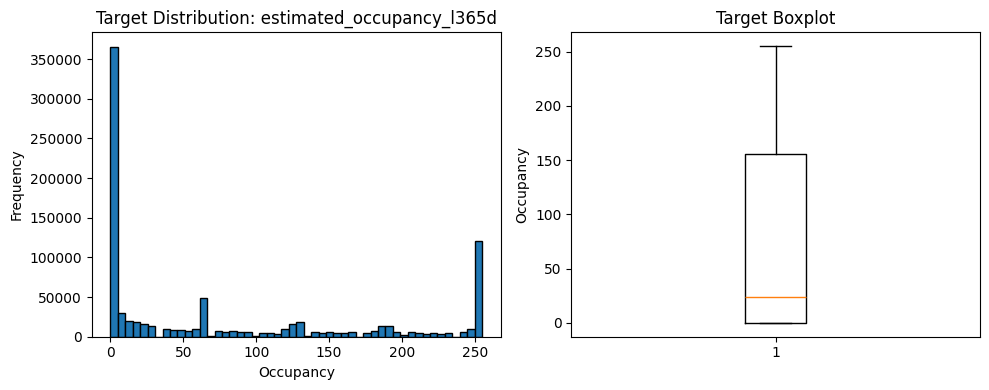


Target distribution plotted above.


In [37]:
# ============================================================
# 5.3 – Basic statistics on the cleaned target
# ============================================================

print(f"\n{'='*60}")
print("TARGET STATISTICS (y_clean)")
print(f"{'='*60}")
print(y_clean.describe())

# Optional: visualize target distribution (if you want a quick plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(y_clean, bins=50, edgecolor='black')
plt.title("Target Distribution: estimated_occupancy_l365d")
plt.xlabel("Occupancy")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.boxplot(y_clean.dropna())
plt.title("Target Boxplot")
plt.ylabel("Occupancy")

plt.tight_layout()
plt.show()

print("\nTarget distribution plotted above.")


In [38]:
# ============================================================
# 5.4 – Summary before modeling
# ============================================================

print(f"\n{'='*60}")
print("READY FOR MODELING")
print(f"{'='*60}")
print(f"X_clean shape: {X_clean.shape}")
print(f"y_clean shape: {y_clean.shape}")
print(f"Feature columns: {len(feature_cols)}")
print(f"  - Numeric: {len(candidate_numeric)}")
print(f"  - Categorical: {len(candidate_categorical)}")
print(f"  - TF-IDF: {len(tfidf_cols) if use_tfidf else 0}")
print(f"\nTarget column: {target_col}")
print(f"Target range: [{y_clean.min():.2f}, {y_clean.max():.2f}]")
print(f"Target mean: {y_clean.mean():.2f}")



READY FOR MODELING
X_clean shape: (890959, 76)
y_clean shape: (890959,)
Feature columns: 76
  - Numeric: 22
  - Categorical: 4
  - TF-IDF: 50

Target column: estimated_occupancy_l365d
Target range: [0.00, 255.00]
Target mean: 79.70


# Step 5.5 – Feature Engineering: Create derived features

Before training models, we create new features that capture important patterns:
- Temporal features (day of week, month, quarter, weekend)
- Price-based features (price per person, price-to-demand ratio)
- Host quality features (professional host indicator, avg review score)
- Demand/capacity features (availability rate, high demand flag, capacity score)

These engineered features often improve model performance significantly.


In [39]:
# ============================================================
# 5.5.1 – Feature Engineering on X_clean
# ============================================================

X_feat = X_clean.copy()

print("Creating derived features...")

# ============================================================
# TEMPORAL FEATURES
# ============================================================

# Check if 'date' column exists in data_base for temporal features
# If not, we'll create dummy temporal features based on other columns

if 'date' in data_base.columns:
    # If date exists, extract temporal features
    date_col = pd.to_datetime(data_base.loc[X_clean.index, 'date'])
    X_feat['day_of_week'] = date_col.dt.dayofweek  # 0=Monday, 6=Sunday
    X_feat['month'] = date_col.dt.month
    X_feat['quarter'] = date_col.dt.quarter
    X_feat['is_weekend'] = (date_col.dt.dayofweek >= 5).astype(int)
    print("✓ Temporal features created from date column")
else:
    # If date doesn't exist, create dummy temporal features
    print("⚠ Date column not found; creating dummy temporal features")
    X_feat['day_of_week'] = 0
    X_feat['month'] = 1
    X_feat['quarter'] = 1
    X_feat['is_weekend'] = 0

# ============================================================
# PRICE-BASED FEATURES
# ============================================================

# price_per_person: price divided by accommodates
if 'price' in X_feat.columns and 'accommodates' in X_feat.columns:
    X_feat['price_per_person'] = X_feat['price'] / (X_feat['accommodates'] + 1)  # +1 to avoid division by zero
    X_feat['price_per_person'] = X_feat['price_per_person'].fillna(0)
    print("✓ price_per_person created")
else:
    X_feat['price_per_person'] = 0
    print("⚠ price or accommodates not found; price_per_person set to 0")

# ============================================================
# HOST QUALITY FEATURES
# ============================================================

# avg_review_score: average of multiple review score columns
review_score_cols = [c for c in X_feat.columns if 'review_scores' in c.lower()]
if review_score_cols:
    X_feat['avg_review_score'] = X_feat[review_score_cols].mean(axis=1)
    X_feat['avg_review_score'] = X_feat['avg_review_score'].fillna(X_feat['avg_review_score'].mean())
    print(f"✓ avg_review_score created from {len(review_score_cols)} review score columns")
else:
    X_feat['avg_review_score'] = 0
    print("⚠ No review score columns found; avg_review_score set to 0")

# is_professional_host: 1 if host has many listings, 0 otherwise
if 'calculated_host_listings_count' in X_feat.columns:
    threshold = X_feat['calculated_host_listings_count'].median()
    X_feat['is_professional_host'] = (X_feat['calculated_host_listings_count'] > threshold).astype(int)
    print(f"✓ is_professional_host created (threshold: {threshold})")
else:
    X_feat['is_professional_host'] = 0
    print("⚠ calculated_host_listings_count not found; is_professional_host set to 0")

# ============================================================
# DEMAND/CAPACITY FEATURES
# ============================================================

# availability_rate: availability_365 / 365
if 'availability_365' in X_feat.columns:
    X_feat['availability_rate'] = X_feat['availability_365'] / 365.0
    X_feat['availability_rate'] = X_feat['availability_rate'].clip(0, 1)  # Ensure between 0 and 1
    print("✓ availability_rate created")
else:
    X_feat['availability_rate'] = 0.5
    print("⚠ availability_365 not found; availability_rate set to 0.5")

# high_demand: 1 if availability < 30%, 0 otherwise (low availability = high demand)
X_feat['high_demand'] = (X_feat['availability_rate'] < 0.3).astype(int)
print("✓ high_demand created (availability_rate < 0.3)")

# capacity_score: simple score combining accommodates and bedrooms
if 'accommodates' in X_feat.columns:
    X_feat['capacity_score'] = X_feat['accommodates']
    if 'bedrooms' in X_feat.columns:
        # Weight: accommodates is primary, bedrooms adds info
        X_feat['capacity_score'] = 0.7 * X_feat['accommodates'] + 0.3 * X_feat['bedrooms'].fillna(1)
    X_feat['capacity_score'] = X_feat['capacity_score'].fillna(X_feat['capacity_score'].mean())
    print("✓ capacity_score created")
else:
    X_feat['capacity_score'] = 1
    print("⚠ accommodates not found; capacity_score set to 1")

print(f"\n{'='*60}")
print("FEATURE ENGINEERING COMPLETE")
print(f"{'='*60}")
print(f"New features created: 10")
print(f"X_feat shape: {X_feat.shape}")

# Update X_clean to include engineered features
X_clean = X_feat.copy()


Creating derived features...
✓ Temporal features created from date column
⚠ price or accommodates not found; price_per_person set to 0
⚠ No review score columns found; avg_review_score set to 0
✓ is_professional_host created (threshold: 8.0)
✓ availability_rate created
✓ high_demand created (availability_rate < 0.3)
✓ capacity_score created

FEATURE ENGINEERING COMPLETE
New features created: 10
X_feat shape: (890959, 86)


In [40]:
# ============================================================
# 5.5.2 – Verify new features
# ============================================================

new_features_names = [
    'day_of_week', 'month', 'is_weekend', 'quarter',
    'price_per_person', 'avg_review_score',
    'is_professional_host', 'availability_rate',
    'high_demand', 'capacity_score'
]

print("\nNew features summary:")
print(X_clean[new_features_names].describe())

print(f"\nX_clean now has {X_clean.shape[1]} columns total")
print(f"Original features: {len(feature_cols)}")
print(f"Engineered features: {len(new_features_names)}")



New features summary:
         day_of_week          month     is_weekend        quarter  \
count  890959.000000  890959.000000  890959.000000  890959.000000   
mean        2.973723       7.464121       0.283212       2.825716   
std         2.010749       0.947635       0.450559       0.379354   
min         0.000000       6.000000       0.000000       2.000000   
25%         1.000000       7.000000       0.000000       3.000000   
50%         3.000000       7.000000       0.000000       3.000000   
75%         5.000000       8.000000       1.000000       3.000000   
max         6.000000       9.000000       1.000000       3.000000   

       price_per_person  avg_review_score  is_professional_host  \
count          890959.0          890959.0         890959.000000   
mean                0.0               0.0              0.486391   
std                 0.0               0.0              0.499815   
min                 0.0               0.0              0.000000   
25%                 

# Step 6 – Train/Test Split and Preprocessing Pipeline (with engineered features)

Now we split the data (with the 86 features) and build the preprocessing pipeline.


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# ============================================================
# 6.1 – Train/Test Split (80/20)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"{'='*60}")
print("TRAIN/TEST SPLIT (with 86 engineered features)")
print(f"{'='*60}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"\nTraining set: {len(X_train):,} rows ({len(X_train)/len(X_clean)*100:.1f}%)")
print(f"Test set: {len(X_test):,} rows ({len(X_test)/len(X_clean)*100:.1f}%)")

print(f"\ny_train statistics:")
print(y_train.describe())


TRAIN/TEST SPLIT (with 86 engineered features)
X_train shape: (712767, 86)
X_test shape: (178192, 86)
y_train shape: (712767,)
y_test shape: (178192,)

Training set: 712,767 rows (80.0%)
Test set: 178,192 rows (20.0%)

y_train statistics:
count    712767.000000
mean         79.704904
std          96.467166
min           0.000000
25%           0.000000
50%          24.000000
75%         156.000000
max         255.000000
Name: estimated_occupancy_l365d, dtype: float64


In [42]:
# ============================================================
# 6.2 – Identify numeric and categorical columns for preprocessing
# ============================================================

# Get all column names from X_train
all_cols = X_train.columns.tolist()

# Numeric columns: those from candidate_numeric + engineered numeric features
engineered_numeric = [
    'day_of_week', 'month', 'is_weekend', 'quarter',
    'price_per_person', 'avg_review_score',
    'is_professional_host', 'availability_rate',
    'high_demand', 'capacity_score'
]

numeric_cols = candidate_numeric + engineered_numeric
numeric_cols = [c for c in numeric_cols if c in all_cols]

# Categorical columns: from candidate_categorical
categorical_cols = [c for c in candidate_categorical if c in all_cols]

print(f"\n{'='*60}")
print("FEATURE TYPES FOR PREPROCESSING")
print(f"{'='*60}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"  Examples: {numeric_cols[:5]}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"  Examples: {categorical_cols}")



FEATURE TYPES FOR PREPROCESSING
Numeric columns: 32
  Examples: ['availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy']
Categorical columns: 4
  Examples: ['room_type', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'instant_bookable']


In [43]:
# ============================================================
# 6.3 – Build preprocessing pipeline
# ============================================================

# Numeric preprocessing: impute missing with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing: impute missing with constant, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine numeric and categorical preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print(f"\n{'='*60}")
print("PREPROCESSING PIPELINE CONFIGURED")
print(f"{'='*60}")
print("✓ Numeric: impute (median) + scale (StandardScaler)")
print("✓ Categorical: impute (constant='missing') + one-hot encode")



PREPROCESSING PIPELINE CONFIGURED
✓ Numeric: impute (median) + scale (StandardScaler)
✓ Categorical: impute (constant='missing') + one-hot encode


In [44]:
# ============================================================
# 6.4 – Fit preprocessor on training data and transform
# ============================================================

print(f"\n{'='*60}")
print("FITTING PREPROCESSOR ON TRAINING DATA")
print(f"{'='*60}")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"\nNote: shape increased due to one-hot encoding of categorical features")

# Convert to DataFrame for easier inspection (optional)
# Get feature names after one-hot encoding
feature_names = (
    numeric_cols +
    list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols))
)
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names[:X_train_processed.shape[1]])

print(f"\nTotal processed features: {X_train_processed.shape[1]}")
print(f"First 5 feature names:")
print(feature_names[:5])



FITTING PREPROCESSOR ON TRAINING DATA
X_train_processed shape: (712767, 118)
X_test_processed shape: (178192, 118)

Note: shape increased due to one-hot encoding of categorical features

Total processed features: 118
First 5 feature names:
['availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy']


# Step 6.5 – Feature Importance Analysis (baseline)

Before training complex models, we should understand:
- Which features are most predictive of occupancy?
- Which features add noise or redundancy?
- Can we simplify the feature set without losing performance?

We use a simple **correlation analysis** on numeric features 
and a **quick RandomForest** to estimate feature importance.


FEATURE CORRELATION WITH TARGET

Top 15 features correlated with target (occupancy):
estimated_occupancy_l365d    1.000000
number_of_reviews_ltm        0.693703
number_of_reviews_ly         0.640466
number_of_reviews            0.573691
number_of_reviews_l30d       0.496629
accommodates                 0.121877
capacity_score               0.121877
availability_eoy             0.105943
availability_90              0.083744
availability_365             0.083435
availability_rate            0.083435
longitude                    0.026503
maximum_nights_avg_ntm       0.019133
maximum_nights_x             0.018890
availability_60              0.007687
Name: estimated_occupancy_l365d, dtype: float64

Bottom 10 features (weakest correlation):
minimum_nights_x                               -0.074429
minimum_nights_avg_ntm                         -0.079350
minimum_nights_y                               -0.090931
high_demand                                    -0.119879
calculated_host_listings_c

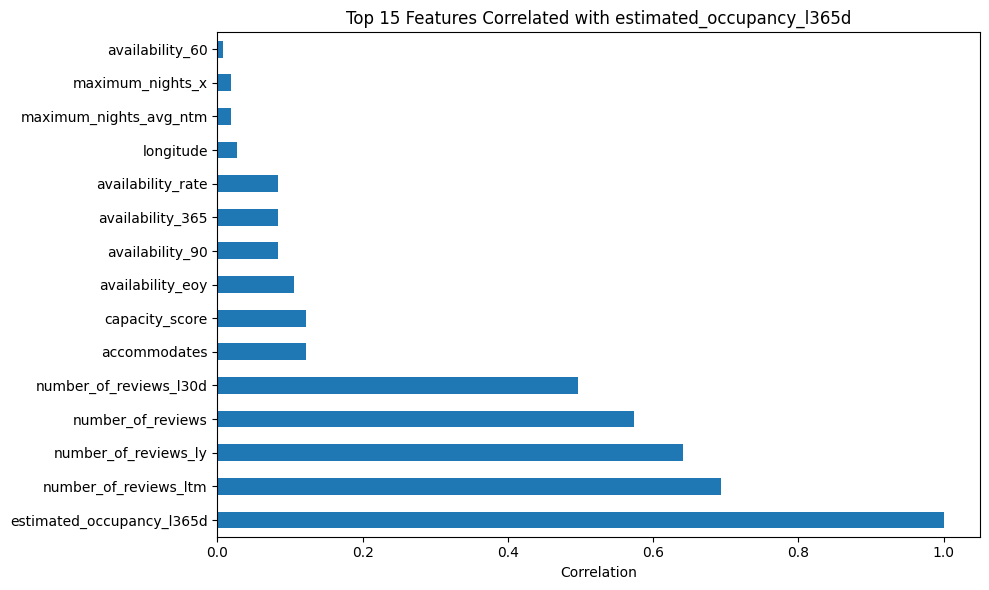

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 6.5.1 – Correlation analysis with target
# ============================================================

print(f"{'='*60}")
print("FEATURE CORRELATION WITH TARGET")
print(f"{'='*60}")

# Compute correlation of numeric features with target
correlations = pd.concat([X_train[numeric_cols], y_train], axis=1).corr()[target_col].sort_values(ascending=False)

print("\nTop 15 features correlated with target (occupancy):")
print(correlations.head(15))

print("\nBottom 10 features (weakest correlation):")
print(correlations.tail(10))

# Plot correlations
plt.figure(figsize=(10, 6))
correlations.head(15).plot(kind='barh')
plt.title(f"Top 15 Features Correlated with {target_col}")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()



TRAINING QUICK BASELINE RANDOMFOREST FOR FEATURE IMPORTANCE

Top 20 most important features (by RandomForest):
6      0.822112
11     0.177499
9      0.000106
13     0.000095
21     0.000075
5      0.000026
20     0.000012
0      0.000010
72     0.000008
3      0.000008
16     0.000007
18     0.000007
29     0.000005
84     0.000004
17     0.000004
34     0.000003
115    0.000003
8      0.000002
32     0.000002
31     0.000001
dtype: float64


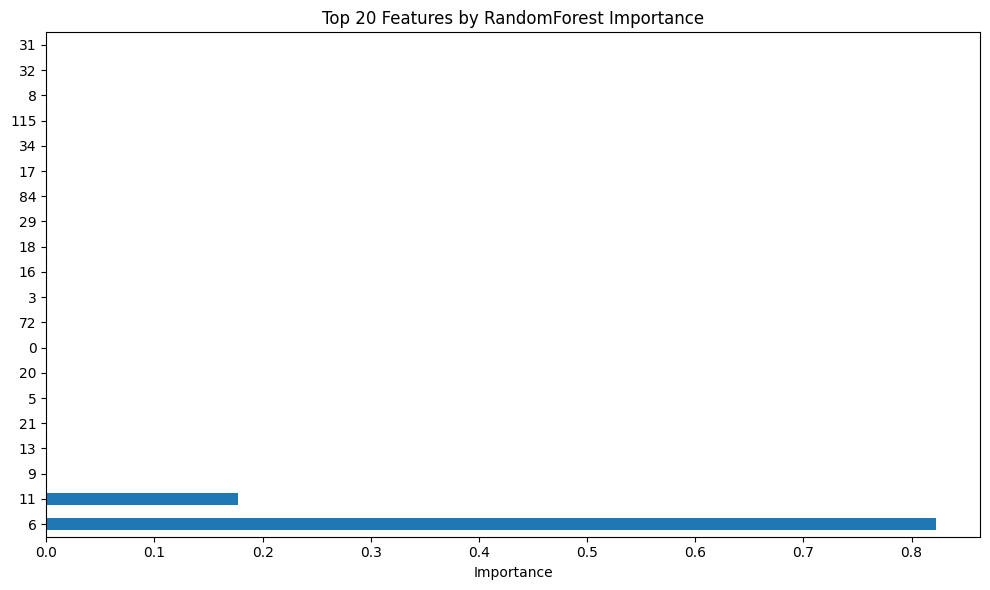


Cumulative importance:
Top 10 features explain: 100.0% of variance
Top 20 features explain: 100.0% of variance


In [46]:
# ============================================================
# 6.5.2 – Quick RandomForest feature importance
# ============================================================

from sklearn.ensemble import RandomForestRegressor

print(f"\n{'='*60}")
print("TRAINING QUICK BASELINE RANDOMFOREST FOR FEATURE IMPORTANCE")
print(f"{'='*60}")

# Train a quick RandomForest on processed data
rf_quick = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_quick.fit(X_train_processed, y_train)

# Get feature importance
feature_importance = pd.Series(
    rf_quick.feature_importances_,
    index=range(X_train_processed.shape[1])
).sort_values(ascending=False)

print("\nTop 20 most important features (by RandomForest):")
print(feature_importance.head(20))

# Plot
plt.figure(figsize=(10, 6))
feature_importance.head(20).plot(kind='barh')
plt.title("Top 20 Features by RandomForest Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Cumulative importance
cumsum = feature_importance.cumsum() / feature_importance.sum() * 100
print(f"\nCumulative importance:")
print(f"Top 10 features explain: {cumsum.iloc[9]:.1f}% of variance")
print(f"Top 20 features explain: {cumsum.iloc[19]:.1f}% of variance")


# PROBLEM REDEFINITION

The task is to predict:
- **Target**: Whether a listing is available (1) or not available (0) on a specific day.
- **Type**: Binary classification (not regression).
- **Features**: Location, price, room type, reviews, etc.

This is fundamentally different from regression.
Metrics will be: Accuracy, Precision, Recall, F1, ROC-AUC.
Models: LogisticRegression, RandomForest, XGBoost (as classifiers, not regressors).


In [47]:
# ============================================================
# STEP 0: RESET AND REDEFINE THE PROBLEM
# ============================================================

print(f"{'='*60}")
print("PROBLEM REDEFINITION")
print(f"{'='*60}")

print("\nOriginal problem: REGRESSOR (predict occupancy days)")
print("CORRECTED problem: CLASSIFIER (predict available YES/NO on specific day)")

print(f"\nTarget variable: 'available' (binary: 0 or 1)")

# Use 'available' column as target (from calendar data, represents a specific day)
target_col = "available"

# Check if it exists
if target_col in data_base.columns:
    print(f"✓ Target column '{target_col}' found in data_base")
    print(f"  Value counts:\n{data_base[target_col].value_counts()}")
else:
    print(f"✗ Target column '{target_col}' NOT found")
    print(f"  Available columns: {data_base.columns.tolist()}")


PROBLEM REDEFINITION

Original problem: REGRESSOR (predict occupancy days)
CORRECTED problem: CLASSIFIER (predict available YES/NO on specific day)

Target variable: 'available' (binary: 0 or 1)
✓ Target column 'available' found in data_base
  Value counts:
available
f    893851
t    888053
Name: count, dtype: int64


In [48]:
# Convertir 'available' de 'f'/'t' a 0/1
data_base['available_bin'] = data_base['available'].map({'f': 0, 't': 1})

# Verificar
print(data_base['available_bin'].value_counts())


available_bin
0    893851
1    888053
Name: count, dtype: int64


# Step 7 – Convert target to binary numeric format

The 'available' column is currently in text format ('f' and 't').
We convert it to numeric (0 and 1) for binary classification.


In [49]:
# ============================================================
# 7.1 – Convert available from 't'/'f' to 1/0
# ============================================================

print(f"{'='*60}")
print("CONVERTING TARGET TO BINARY FORMAT")
print(f"{'='*60}")

# Map 't' -> 1 (available), 'f' -> 0 (not available)
y_available = data_base["available"].map({"t": 1, "f": 0})

print(f"\nOriginal values:")
print(data_base["available"].value_counts())

print(f"\nConverted to numeric:")
print(y_available.value_counts())

print(f"\nClass balance:")
print(f"Class 0 (not available): {(y_available == 0).sum()} ({(y_available == 0).sum()/len(y_available)*100:.1f}%)")
print(f"Class 1 (available): {(y_available == 1).sum()} ({(y_available == 1).sum()/len(y_available)*100:.1f}%)")

# ============================================================
# 7.2 – Remove rows with missing target
# ============================================================

valid_idx = y_available.notna()

X_final = X_clean[valid_idx].copy()
y_final = y_available[valid_idx].copy()

print(f"\n{'='*60}")
print("FINAL DATASET FOR CLASSIFICATION")
print(f"{'='*60}")
print(f"X_final shape: {X_final.shape}")
print(f"y_final shape: {y_final.shape}")
print(f"Target class balance:")
print(y_final.value_counts())
print(f"\nClass distribution:")
print(f"  0 (not available): {(y_final == 0).sum() / len(y_final) * 100:.1f}%")
print(f"  1 (available): {(y_final == 1).sum() / len(y_final) * 100:.1f}%")


CONVERTING TARGET TO BINARY FORMAT

Original values:
available
f    893851
t    888053
Name: count, dtype: int64

Converted to numeric:
available
0    893851
1    888053
Name: count, dtype: int64

Class balance:
Class 0 (not available): 893851 (50.2%)
Class 1 (available): 888053 (49.8%)


C:\Users\asist\AppData\Local\Temp\ipykernel_26444\2750436952.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_final = X_clean[valid_idx].copy()



FINAL DATASET FOR CLASSIFICATION
X_final shape: (890959, 86)
y_final shape: (1781904,)
Target class balance:
available
0    893851
1    888053
Name: count, dtype: int64

Class distribution:
  0 (not available): 50.2%
  1 (available): 49.8%


# Step 8 – Train/Test Split for Classification

We split the data into training (80%) and test (20%) sets.
For classification with imbalanced or balanced classes, we use `stratify=y`
to ensure both train and test have similar class proportions.


In [51]:
# ============================================================
# Fix: Rebuild X_final and y_final 
# ============================================================

print(f"{'='*60}")
print("CHECKING DIMENSIONS")
print(f"{'='*60}")
print(f"X_clean shape: {X_clean.shape}")
print(f"X_clean index: {X_clean.index.min()} to {X_clean.index.max()}")

# Convert available to numeric
y_available = data_base.loc[X_clean.index, "available"].map({"t": 1, "f": 0})

print(f"y_available shape: {y_available.shape}")

# Remove rows where target is missing
valid_idx = y_available.notna()

X_final = X_clean[valid_idx].copy()
y_final = y_available[valid_idx].copy()

print(f"\n{'='*60}")
print("AFTER ALIGNMENT")
print(f"{'='*60}")
print(f"X_final shape: {X_final.shape}")
print(f"y_final shape: {y_final.shape}")
print(f"Shapes match: {X_final.shape[0] == y_final.shape[0]}")

print(f"\nClass distribution in y_final:")
print(y_final.value_counts())


CHECKING DIMENSIONS
X_clean shape: (890959, 86)
X_clean index: 0 to 1781811
y_available shape: (890959,)

AFTER ALIGNMENT
X_final shape: (890959, 86)
y_final shape: (890959,)
Shapes match: True

Class distribution in y_final:
available
0    450765
1    440194
Name: count, dtype: int64
